In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA

# --- Quandela / MerLin ---
import merlin as ML  # pip install merlinquantum

# ============================================================
# 0. LOAD XLSX + remove first column
# ============================================================
raw = pd.read_excel("train.xlsx").values
dataset_train = raw[:, 1:]


# ============================================================
# 1. PCA 2D
# ============================================================
def compute_pca(data):
    pca = PCA(n_components=2)
    data2 = pca.fit_transform(data)
    return data2, pca


# ============================================================
# 2. Windows t1–t3 → t4–t6
# ============================================================
def make_windows(data2):
    X, Y = [], []
    T = len(data2)
    for t in range(T - 6):
        X.append(data2[t:t+3])      # shape (3, 2)
        Y.append(data2[t+3:t+6])    # shape (3, 2)
    return np.array(X), np.array(Y)


# ============================================================
# 3. Dataset
# ============================================================
class TimeDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.Y[i]


# ============================================================
# 4. MerLin quantum layer (simple interface)
#    Input: (B, 3, 2) -> flatten to (B, 6)
# ============================================================
class MerlinTimeModel(nn.Module):
    def __init__(self, input_size=6, n_params=50):
        """
        Simple hybrid model:
         - MerLin QuantumLayer.simple for the quantum block
         - Linear(quantum_output_size -> 6) to map back to 3x2 window
        """
        super().__init__()

        # Photonic quantum layer of size=6, output size=variable
        self.q_layer = ML.QuantumLayer.simple(
            input_size=input_size,
            n_params=n_params
        )

        # of size quantum_output_size, output size=6 (3x2 window)
        self.fc = nn.Linear(self.q_layer.output_size, 6)

    def forward(self, x):
        """
        x: (B, 3, 2)
        returns: (B, 3, 2)
        """
        B = x.shape[0]
        # Flatten 3x2 window -> 6 features
        x_flat = x.view(B, -1)              # (B, 6)

        # Quantum forward pass
        q_out = self.q_layer(x_flat)        # (B, q_dim)

        # Classical linear head
        y = self.fc(q_out)                  # (B, 6)

        # Reshape back to (3, 2) window
        return y.view(B, 3, 2)


# ============================================================
# 5. Training
# ============================================================
def train_model(dataset_train, epochs=20, bs=8, n_params=50):
    # 1) PCA to 2D
    data2, pca = compute_pca(dataset_train)

    # 2) Build windows t1–t3 → t4–t6
    X, Y = make_windows(data2)

    # 3) Dataloader
    loader = DataLoader(TimeDataset(X, Y), batch_size=bs, shuffle=True)

    # 4) Hybrid MerLin model
    model = MerlinTimeModel(input_size=6, n_params=n_params)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    # 5) Training loop
    for epoch in range(epochs):
        tot = 0.0
        for xb, yb in loader:
            pred = model(xb)
            loss = loss_fn(pred, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            tot += loss.item()
        print("epoch", epoch, "loss", tot / len(loader))

    return model, pca


# ============================================================
# 6. Autoregressive prediction
# ============================================================
def generate_next(model, pca, dataset_train, steps=2):
    # Take last 3 original points (high-dim)
    last3 = dataset_train[-3:]

    # Project them to PCA space (3, 2)
    seq = pca.transform(last3)

    gen = []

    for _ in range(steps):
        # Current context: last 3 PCA points
        inp = torch.tensor(seq[-3:], dtype=torch.float32).unsqueeze(0)  # (1,3,2)
        out = model(inp)[0].detach().numpy()                            # (3,2)

        gen.append(out)
        # Append predicted 3 steps to the sequence
        seq = np.vstack([seq, out])

    gen = np.vstack(gen)  # shape (3*steps, 2)

    # Inverse PCA back to original feature space
    return pca.inverse_transform(gen)


# ============================================================
# RUN TRAINING + GENERATION
# ============================================================
if __name__ == "__main__":
    model, pca = train_model(dataset_train)

    future_points = generate_next(model, pca, dataset_train, steps=2)

    # ========================================================
    # 7. Build final dataset (Tenor/Maturity grid)
    # ========================================================
    tenors = [1,2,3,4,5,6,7,8,9,10,15,20,25,30]
    maturities = [
        0.0833333333333333, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 7, 10,
        15, 20, 25, 30
    ]

    columns = []
    for mat in maturities:
        for ten in tenors:
            columns.append(f"Tenor : {ten}; Maturity : {mat}")

    dates = [
        "24/12/2051",
        "26/12/2051",
        "27/12/2051",
        "29/12/2051",
        "30/12/2051",
        "01/01/2052"
    ]

    N = len(dates)
    final_data = future_points[:N, :len(columns)]

    df_final = pd.DataFrame(final_data, columns=columns)
    df_final.insert(0, "Date", dates)

    print(df_final)
    df_final.to_excel("final_dataset.xlsx", index=False)


C:\Users\naama\AppData\Local\Temp\ipykernel_20668\3387021654.py:68: RuntimeWarning: Entangling layer introduces 90 trainable parameters, exceeding the requested budget of 50. The simple layer will expose 90 trainable parameters.
  self.q_layer = ML.QuantumLayer.simple(


epoch 0 loss 0.04239148625563229
epoch 1 loss 0.0384478471542318
epoch 2 loss 0.03376950913920037
epoch 3 loss 0.02908923053332875
epoch 4 loss 0.02530874664925279
epoch 5 loss 0.02247740887105465
epoch 6 loss 0.020663416636506875
epoch 7 loss 0.019238643558515657
epoch 8 loss 0.018314122267427943
epoch 9 loss 0.017573265156017676
epoch 10 loss 0.01683874491361841
epoch 11 loss 0.016090508708129485
epoch 12 loss 0.015340111834267455
epoch 13 loss 0.014598062697557672
epoch 14 loss 0.013666340442855031
epoch 15 loss 0.012958013685420156
epoch 16 loss 0.011981104335357104
epoch 17 loss 0.011281582699607938
epoch 18 loss 0.010740559750927551
epoch 19 loss 0.009984847518705552
         Date  Tenor : 1; Maturity : 0.0833333333333333  \
0  24/12/2051                                  0.028966   
1  26/12/2051                                  0.029014   
2  27/12/2051                                  0.029125   
3  29/12/2051                                  0.028473   
4  30/12/2051          

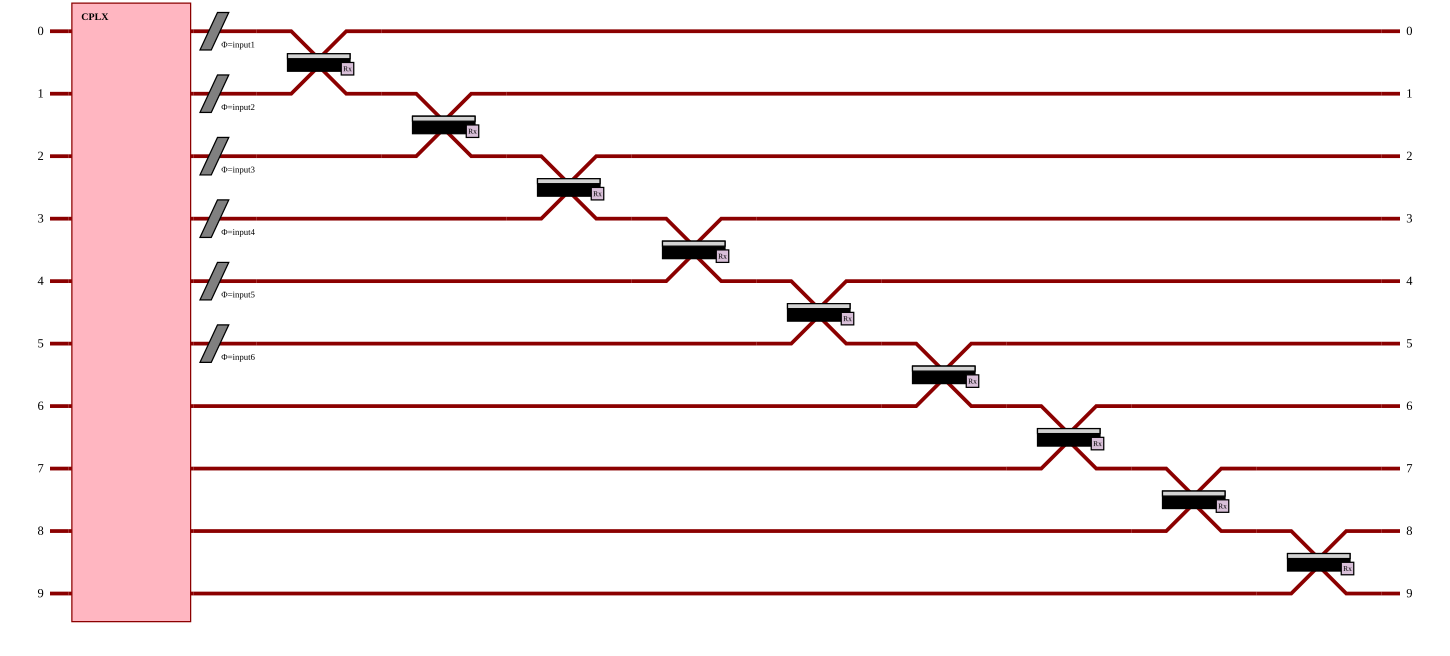

In [13]:
import perceval as pcvl

# Draw circuit
q_layer = model.q_layer        
circ = q_layer.circuit

pcvl.pdisplay(circ)


In [ ]:
from perceval import RemoteConfig, RemoteProcessor
PLATFORM_SIM = "sim:slos"
PLATFORM_QPU = "qpu:ascella"   # or "qpu:belenos" etc.
# Save your token and proxy configuration into Perceval persistent data, you only need to do it once per machine.
remote_config = RemoteConfig()
remote_config.set_token("mytoken")  # Replace with your Token from the Cloud
remote_config.save()
remote_processor = RemoteProcessor(PLATFORM_QPU)
remote_processor.min_detected_photons_filter(1)


In [ ]:
# ============================================================
# QPU vs Simulator: price prediction + loss
# ============================================================
import math
import time
import numpy as np
import torch
import perceval as pcvl
from perceval.algorithm import Sampler
from torch.nn import MSELoss

# ------------------------------------------------------------
# 0) Helpers: encode window -> phase, probs -> feature vector
# ------------------------------------------------------------
def window_to_phi(window_3x2: np.ndarray) -> float:
    """
    Map a 3x2 PCA window to a single phase angle in [0, 2π].
    Very rough encoding; you can improve later.
    """
    v = window_3x2.reshape(-1)
    v_mean = float(v.mean())
    v_clamped = max(-3.0, min(3.0, v_mean))
    return (v_clamped + 3.0) / 6.0 * 2 * math.pi

# basis states used as quantum features: |2,0>, |1,1>, |0,2>
basis_states = [
    pcvl.BasicState([2, 0]),
    pcvl.BasicState([1, 1]),
    pcvl.BasicState([0, 2]),
]

def probs_to_features(probs_dict) -> np.ndarray:
    """
    Convert probability distribution over Fock states
    into a 3-dim feature vector.
    """
    feats = [probs_dict.get(s, 0.0) for s in basis_states]
    return np.array(feats, dtype=np.float32)


# ------------------------------------------------------------
# 1) Simulator prediction (MerLin model) – target prices
# ------------------------------------------------------------
steps = 1  # number of autoregressive steps compared on QPU
future_points_sim = generate_next(model, pca, dataset_train, steps=steps)
# shape: [steps*3, price_dim]
target_prices = future_points_sim  # (3, D) since steps=1


# ------------------------------------------------------------
# 2) Build circuit for the last 3 PCA points
# ------------------------------------------------------------
last3 = dataset_train[-3:]          # last 3 original points
seq_pca = pca.transform(last3)      # (3,2) PCA window
phi = window_to_phi(seq_pca)

input_state = pcvl.BasicState([1, 1])   # 2 photons in 2 modes

c = pcvl.Circuit(2)
c.add(0, pcvl.BS())                 # beamsplitter
c.add(0, pcvl.PS(phi=phi))          # phase shifter with data-dependent angle
c.add(0, pcvl.BS())                 # another beamsplitter

# Optional visual check
# pcvl.pdisplay(c)

# ------------------------------------------------------------
# 3) Choose the hardware platform (real QPU)
# ------------------------------------------------------------
remote_qpu = pcvl.RemoteProcessor(PLATFORM_QPU)
remote_qpu.set_circuit(c)
remote_qpu.with_input(input_state)

# Only keep events with 2 detected photons
remote_qpu.min_detected_photons_filter(2)

# ------------------------------------------------------------
# 4) Sample on the real QPU
# ------------------------------------------------------------
nsamples = 10_000
required_shots = remote_qpu.estimate_required_shots(nsamples=nsamples)
print(f"To get ~{nsamples} 2-photon events, QPU needs about {required_shots} shots.")

sampler = Sampler(remote_qpu, max_shots_per_call=required_shots)
remote_job = sampler.sample_count.execute_async(nsamples)
print("Submitted job:", remote_job.id)

while not remote_job.is_complete:
    print("Job status:", remote_job.status(), "... waiting")
    time.sleep(2)

print("Final status:", remote_job.status())

results = remote_job.get_results()
counts = results["results"]   # dict: BasicState -> counts

total = sum(counts.values())
probs = {state: cnt / total for state, cnt in counts.items()}

print("\nQPU empirical probabilities:")
for state, p in probs.items():
    print(f"{state}: {p:.4f}")

# ------------------------------------------------------------
# 5) QPU probs -> features -> PCA next step -> prices
# ------------------------------------------------------------
# quantum features z in R^3
z = probs_to_features(probs)                      # (3,)
z_t = torch.tensor(z, dtype=torch.float32).unsqueeze(0)  # [1,3]




To get ~10000 2-photon events, QPU needs about 809672 shots.
Submitted job: 0cbf4275-134b-47a7-abab-a68e4fc851b1
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ... waiting
Job status: WAITING ...

NameError: name 'price_head' is not defined